In [1]:
from py_files.setup import *
setup_notebook()

# `Inequality measures`

Plotting the evolution in the CIT against the gini and the labour share.

*`1. Get data`*

In [2]:
# 1. Gini, fix comma to dot
gini = pd.read_csv('0_raw_data/IFOR41.csv', sep=';', decimal=',')
gini = gini[gini['TID'] >= 1990]

# 2. intangibles
years = range(1990, 2024)
investment_timeseries = il.compute_investment_timeseries(
    years=years, 
    normalize_by_gdp=True  
)

Processing year 1990...
Processing year 1991...
Processing year 1992...
Processing year 1993...
Processing year 1994...
Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...

Fetching GDP data for normalization...
  Normalized by GDP


*`2. Plot all`*

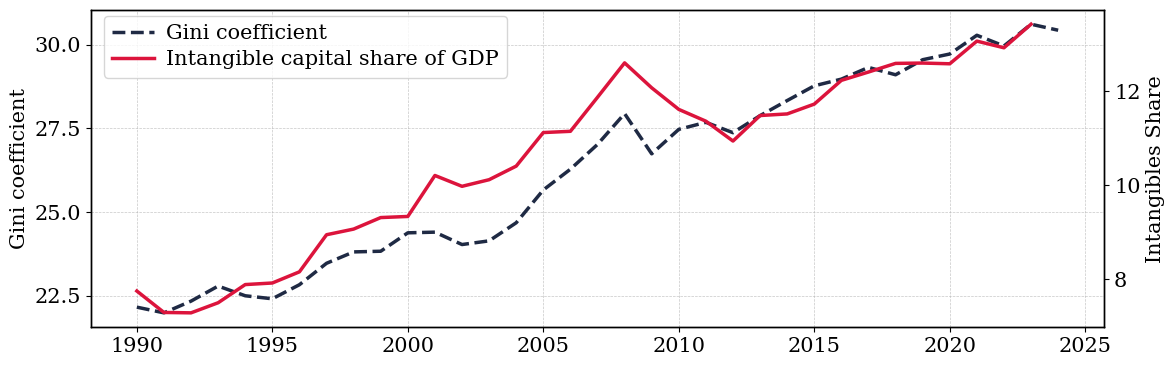

In [34]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))
ax1_twin = ax1.twinx()

line1 = ax1.plot(gini.TID, gini.INDHOLD, 
                 label='Gini coefficient', linewidth=2.5, 
                 color='#1F2A44', ls='--')

line2 = ax1_twin.plot(
    investment_timeseries.index,
    investment_timeseries.intangible,
    label='Intangible capital share of GDP', linewidth=2.5, color='crimson')

# ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient")
ax1_twin.set_ylabel("Intangibles Share")
# ax1.set_title("Gini Coefficient vs Intangibles Share", pad=15)
ax1.grid(True, which="both", linestyle="--", alpha=0.7, linewidth=0.5)
ax1.locator_params(axis='y', nbins=4)
ax1_twin.locator_params(axis='y', nbins=4)

lines = line1 + line2
labels = [l.get_label() for l in lines]

fig.legend(lines, labels, loc='upper left', 
           ncol=1, frameon=True, bbox_to_anchor=(0.09, 0.95))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('0_output/corr_arg.png')
plt.show()